# Gender Classification With Navie Bayer's Algorithm 

## Business Problem

A facial feature–based classification system is required to identify whether a person is Male or Female using physical facial attributes such as forehead dimensions, nose shape, lip thickness, and hair characteristics.

The organization wants to build a machine learning classification model that can automatically predict gender based on these facial measurements. This system can help in applications like:

Face recognition systems
Human-computer interaction
Demographic analysis
Security and surveillance systems
AI-based image processing applications

To solve this problem, the Naive Bayes Algorithm will be used because it is simple, fast, and effective for classification problems.

## Data Dictionary
| Column Name                 | Data Type     | Description                                                                  |
| --------------------------- | ------------- | ---------------------------------------------------------------------------- |
| `long_hair`                 | Integer (0/1) | Indicates whether the person has long hair. 1 = Yes, 0 = No                  |
| `forehead_width_cm`         | Float         | Width of the forehead measured in centimeters                                |
| `forehead_height_cm`        | Float         | Height of the forehead measured in centimeters                               |
| `nose_wide`                 | Integer (0/1) | Indicates whether the nose is wide. 1 = Yes, 0 = No                          |
| `nose_long`                 | Integer (0/1) | Indicates whether the nose is long. 1 = Yes, 0 = No                          |
| `lips_thin`                 | Integer (0/1) | Indicates whether the lips are thin. 1 = Yes, 0 = No                         |
| `distance_nose_to_lip_long` | Integer (0/1) | Indicates whether the distance between nose and lip is long. 1 = Yes, 0 = No |
| `gender`                    | Categorical   | Target variable representing gender (Male/Female)                            |


## Problem Statement

The objective of this project is to analyze facial feature data and develop a predictive classification model using the Naive Bayes Algorithm to determine whether a person is Male or Female

## Importing Datasets


In [39]:
# importing Libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings( "ignore")

# Ml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
# from sklearn.model_selection import cross_val_score

In [2]:
# Importing Dataset 

df = pd.read_csv('gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


### Exploratory Data Analysis

In [3]:
df.shape

(5001, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [5]:
df.isnull().sum()

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

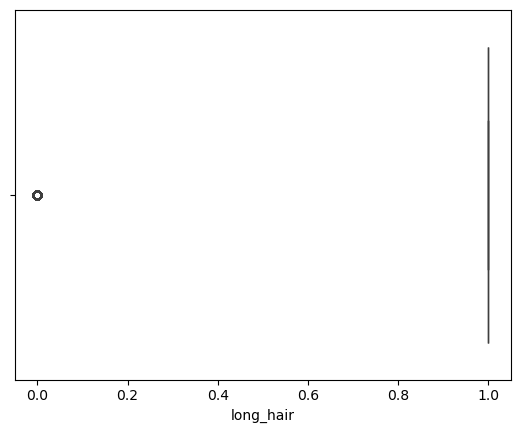

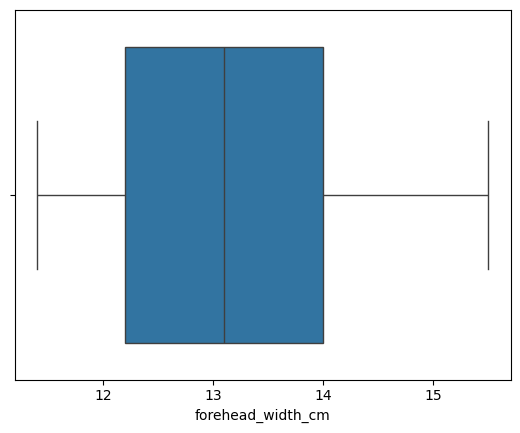

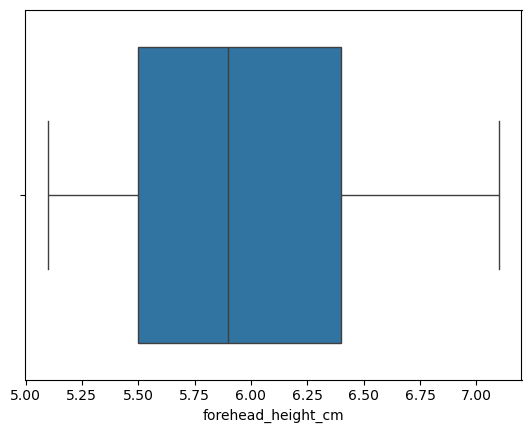

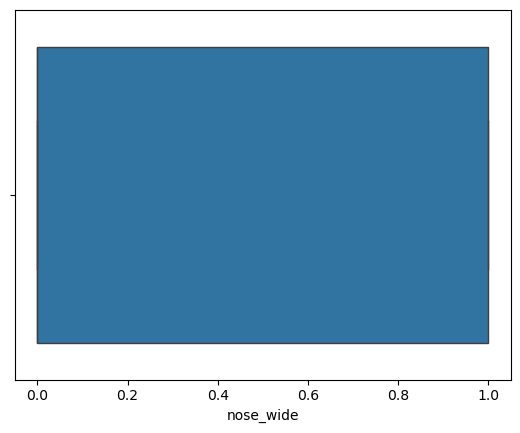

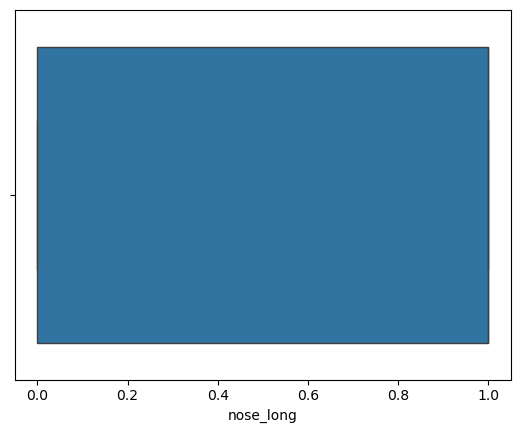

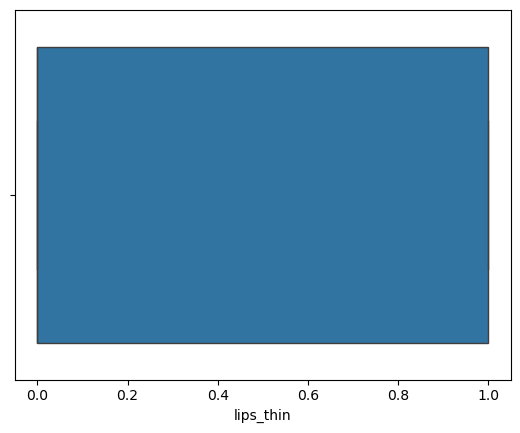

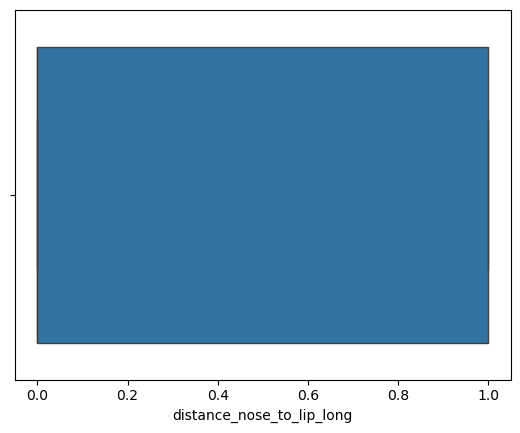

In [12]:
# checking for the Outliers 

num_df = df.select_dtypes('number')

for i in num_df.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

### Train test Split

In [13]:
X = df.drop('gender',axis=1)
y = df.gender

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=6)

In [14]:
Xtrain.shape

(4000, 7)

In [16]:
ytrain.shape

(4000,)

In [24]:
# Treatment For the Outliers 
num_cols=Xtrain.select_dtypes(include='number').columns

for i in num_cols:
    q1=Xtrain[i].quantile(0.25)
    q3=Xtrain[i].quantile(0.75)
    iqr=q3-q1
    uc=q3+1.5*iqr
    lc=q1-1.5*iqr
    Xtrain[i]=Xtrain[i].clip(lower=lc,upper=uc)
    Xtest[i]=Xtest[i].clip(lower=lc,upper=uc)

In [26]:
from scipy.stats import shapiro
for i in num_df.columns:
    stat,pvalue=shapiro(df[i])
    print('P value for',i,'is',round(pvalue,2))

P value for long_hair is 0.0
P value for forehead_width_cm is 0.0
P value for forehead_height_cm is 0.0
P value for nose_wide is 0.0
P value for nose_long is 0.0
P value for lips_thin is 0.0
P value for distance_nose_to_lip_long is 0.0


### Scaling 

In [29]:
scale=MinMaxScaler()

In [30]:
num_cols

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long'],
      dtype='object')

In [31]:
Xtrain[num_cols]=scale.fit_transform(Xtrain[num_cols])
Xtest[num_cols]=scale.transform(Xtest[num_cols])

In [32]:
# RFE 

In [35]:
model=LogisticRegression()

In [36]:
rfe=RFE(estimator=model,n_features_to_select=5)

In [37]:
rfe.fit_transform(Xtrain,ytrain)

array([[0.53658537, 0.        , 0.        , 0.        , 1.        ],
       [0.19512195, 1.        , 0.        , 1.        , 0.        ],
       [0.51219512, 0.        , 0.        , 1.        , 1.        ],
       ...,
       [0.12195122, 0.        , 0.        , 0.        , 0.        ],
       [0.90243902, 1.        , 1.        , 1.        , 1.        ],
       [0.80487805, 1.        , 1.        , 1.        , 1.        ]],
      shape=(4000, 5))

In [38]:
pd.DataFrame(data={
'Feature':Xtrain.columns,'Ranking':rfe.ranking_}).sort_values(by='Ranking')

,Feature,Ranking
1,forehead_width_cm,1
3,nose_wide,1
4,nose_long,1
5,lips_thin,1
6,distance_nose_to_lip_long,1
2,forehead_height_cm,2
0,long_hair,3


In [40]:
Xtrain=Xtrain[[ 'forehead_width_cm','nose_wide','nose_long','lips_thin','distance_nose_to_lip_long']]
Xtest=Xtest[[ 'forehead_width_cm','nose_wide','nose_long','lips_thin','distance_nose_to_lip_long']]

### Modelling

In [41]:
gnb=GaussianNB()
m1=gnb.fit(Xtrain,ytrain)

In [42]:
train_pred=m1.predict(Xtrain)
test_pred=m1.predict(Xtest)

In [43]:
metrics.confusion_matrix(ytrain,train_pred)

array([[1950,   66],
       [  79, 1905]])

In [44]:
print(metrics.classification_report(ytrain,train_pred))

              precision    recall  f1-score   support

      Female       0.96      0.97      0.96      2016
        Male       0.97      0.96      0.96      1984

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



In [48]:
# ROC and AUC Possibilities

train_prob=m1.predict_proba(Xtrain)[:,1]
pd.DataFrame(train_prob)

,0
0,1.635185e-03
1,4.093766e-01
2,5.625395e-01
3,1.375805e-03
4,9.993566e-01
...,...
3995,9.998528e-01
3996,9.998898e-01
3997,8.009451e-07
3998,9.999999e-01


In [49]:
metrics.roc_auc_score(ytrain,train_prob)

0.9957631038386456

Here 99% model is able to classify data points correctly

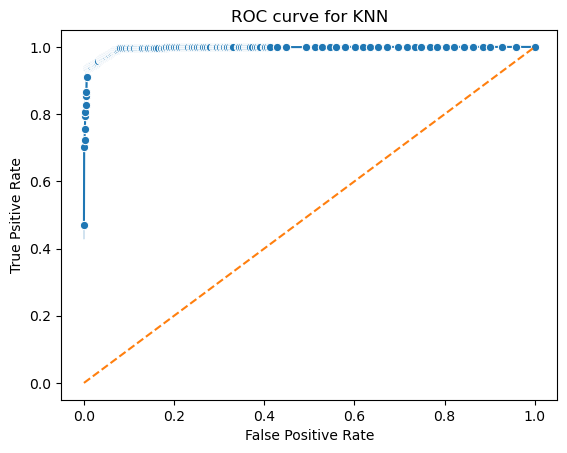

In [54]:
# ROC Curve 

fpr,tpr,threshold=metrics.roc_curve(ytrain,train_prob,pos_label='Male')
sns.lineplot(x=fpr,y=tpr, marker='o')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('ROC curve for KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Psitive Rate')
plt.show()

In [55]:
metrics.confusion_matrix(ytest,test_pred)

array([[465,  20],
       [ 16, 500]])

In [56]:
print(metrics.classification_report(ytest,test_pred))

              precision    recall  f1-score   support

      Female       0.97      0.96      0.96       485
        Male       0.96      0.97      0.97       516

    accuracy                           0.96      1001
   macro avg       0.96      0.96      0.96      1001
weighted avg       0.96      0.96      0.96      1001



In [57]:
test_prob=m1.predict_proba(Xtest)[:,1]
pd.DataFrame(test_prob)

,0
0,9.999980e-01
1,1.924010e-06
2,9.999987e-01
3,1.591156e-06
4,8.013916e-07
...,...
996,3.545129e-01
997,2.113016e-03
998,9.999983e-01
999,3.908757e-06


In [58]:
metrics.roc_auc_score(ytest,test_prob)

0.9965675697274834

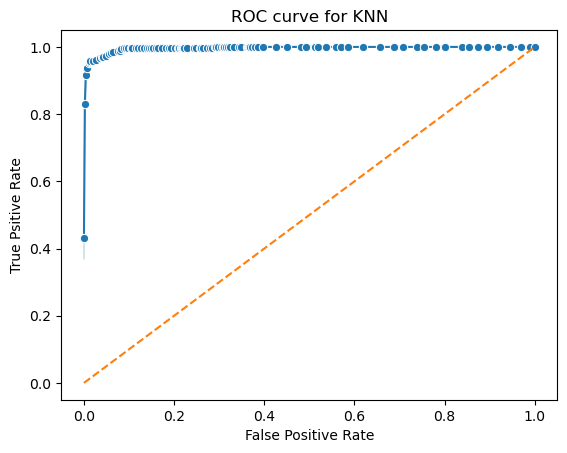

In [61]:
fpr,tpr,threshold=metrics.roc_curve(ytest,test_prob,pos_label='Male')
sns.lineplot(x=fpr,y=tpr, marker='o')
plt.plot([0,1],[0,1],linestyle='--')
plt.title('ROC curve for KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Psitive Rate')
plt.show()

In [62]:
# Save Model 
import pickle
with open("Final_Salary_Predictions.pkl", "wb") as f:
    pickle.dump(model, f)

pickle.dump(X.columns, open("columns.pkl", "wb"))

NameError: name 'joblib' is not defined